# SAR5 · Learning Sentiment from Examples: TF-IDF and Logistic Regression

A lexicon (SAR2) relies on a human-written word list. A classifier instead *learns* which words matter from labelled examples. This notebook trains the standard baseline text classifier, evaluates it honestly, and compares it with the lexicon. It ends with a pointer to modern language models.

## 1. Motivation

The SAR2 lexicon missed "writes down value", "strengthens reserves" and "licensing deal", because nobody had put those words on the list. With enough labelled examples, a model can discover such phrases by itself. It can also pick up two-word patterns like "not as" or "lower than". But learning from examples brings the familiar risk from the Signal Research track: a model can look brilliant on the data it learned from and fail on new data. With only 120 headlines, honest evaluation matters even more.

## 2. Intuition

1. **Turn each headline into a vector of word weights.** Words that appear in a headline get a weight. Words that are rare across all headlines get *more* weight than common ones ("recall" says more than "the" or "company"). This weighting is called **TF-IDF**.
2. **Learn a weight per word for each sentiment class.** A **logistic regression** learns, for example, that "beats" pushes towards positive and "recall" towards negative, by adjusting the weights until its predictions match the labels in the training data.
3. **Test on headlines it hasn't seen.** And make sure "unseen" really means unseen. If the same company appears in training and test, the model may learn the company's *name* instead of the language of good and bad news.

## 3. The math

**TF-IDF.** For term $w$ in headline $d$, out of $D$ headlines in total:
$$
\text{tfidf}(w, d) = \text{tf}(w,d)\times \log\frac{1 + D}{1 + \text{df}(w)} + 1 ,
$$
where $\text{tf}$ is the count of $w$ in $d$, and $\text{df}(w)$ is the number of headlines containing $w$. Each headline's vector is then scaled to length 1. Terms can be single words or **bigrams** (two-word phrases such as "not as").

**Multinomial logistic regression.** With classes $k \in \{\text{neg}, \text{neu}, \text{pos}\}$ and a weight vector $\theta_k$ per class, the predicted probability of class $k$ for a headline with TF-IDF vector $x$ is
$$
\Pr(k \mid x) = \frac{e^{\theta_k^\top x}}{\sum_{j} e^{\theta_j^\top x}} .
$$
The weights maximise the log-likelihood of the training labels minus a penalty $\frac{1}{2C}\sum_k \|\theta_k\|^2$. The penalty (controlled by $C$) stops the model from giving huge weights to words seen only once. That kind of overfitting is a real danger with 120 examples and hundreds of distinct words.

**Evaluation.** $K$-fold cross-validation, as in SR6. **Grouped** folds keep every headline about the same company in the same fold, so test companies are always new to the model.

## 4. Code it

### 4.1 Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_predict

warnings.filterwarnings("ignore")
news = pd.read_csv("../data/sample_headlines.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

def remove_company(row):
    """Strip the company name so the model has to learn from the news language itself."""
    return row["headline"].replace(row["company"], "").strip()

news["text"] = news.apply(remove_company, axis=1)
print(news[["headline", "text"]].head(3).to_string(index=False))

                                                                 headline                                                   text
Northwind Robotics beats earnings estimates and raises full-year guidance beats earnings estimates and raises full-year guidance
    Northwind Robotics shares surge after landing record defense contract     shares surge after landing record defense contract
                Northwind Robotics misses revenue forecast as orders slow                 misses revenue forecast as orders slow


### 4.2 The model

In [2]:
def make_classifier(C=5.0):
    return make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),   # words and two-word phrases
        LogisticRegression(C=C, max_iter=2000),                    # multinomial logistic regression
    )

### 4.3 Honest evaluation: three ways to split

In [3]:
y = news["label"].values
results = {}

# (a) Train and test on the same 120 headlines: the number you should never report
clf = make_classifier().fit(news["text"], y)
results["Training accuracy (in-sample)"] = (clf.predict(news["text"]) == y).mean()

# (b) Stratified 5-fold CV: each fold keeps the class balance; companies are mixed across folds
pred_strat = cross_val_predict(make_classifier(), news["text"], y,
                               cv=StratifiedKFold(5, shuffle=True, random_state=0))
results["5-fold CV"] = (pred_strat == y).mean()

# (c) Grouped CV: all headlines about a company are in the same fold, so test companies are new
pred_group = cross_val_predict(make_classifier(), news["text"], y,
                               cv=GroupKFold(n_splits=6), groups=news["company"])
results["Grouped CV (new companies)"] = (pred_group == y).mean()
pd.Series(results).map("{:.0%}".format)

Training accuracy (in-sample)    100%
5-fold CV                         51%
Grouped CV (new companies)        57%
dtype: object

- **In-sample, the classifier is perfect (100%).** With hundreds of distinct words and only 120 headlines, it can simply memorise every training example. The number is meaningless.
- **On unseen headlines it gets 51–57% right.** That is better than the 35% from always guessing the most common class, but far from perfect. Small changes in the splits move the result by several points, which is normal with so little data.

We removed company names from the text for the same reason. Left in, they would let the classifier partly learn which companies had more good news, a pattern that only works for companies it has already seen. Grouped splits are the check that this isn't happening.

### 4.4 Lexicon vs. classifier on the same test folds

The lexicon from SAR2 has no training step, so we can apply it to every headline directly. That is still optimistic for the lexicon, since its word list was written with this kind of headline in mind.

In [4]:
POSITIVE = {"beat", "beats", "surge", "surges", "soar", "soars", "jump", "jumps", "record", "rise", "rises",
            "raise", "raises", "raised", "growth", "grows", "strong", "upgrade", "upgraded", "approval",
            "approves", "succeeds", "wins", "win", "expand", "expands", "boost", "boosts", "profit",
            "improves", "improving", "recover", "recovers", "tops", "secures", "lifts", "high", "best",
            "premium", "confidence", "lowers"}
NEGATIVE = {"miss", "misses", "missed", "cut", "cuts", "lawsuit", "sued", "fails", "fail", "failed",
            "plunge", "plunges", "tumble", "tumbles", "recall", "recalls", "warns", "weak", "weaker",
            "weaken", "decline", "declines", "drop", "drops", "falls", "fall", "losses", "loss",
            "downgraded", "investigation", "fine", "breach", "outage", "layoffs", "lays", "close",
            "strike", "delayed", "delays", "disappoint", "disappoints", "rejects", "defaults", "halts",
            "grounds", "cancels", "squeeze", "hurt", "violations", "risks", "shortage", "disruption",
            "resigns", "short", "slow", "slows", "glut", "liability", "denied", "worst", "bad"}
NEGATORS = {"not", "no", "never", "without", "cannot", "can't", "didn't", "isn't", "nor", "avoids", "avoid"}

def lexicon_label(text):
    toks = re.findall(r"[a-z']+", text.lower())
    P = N = 0
    for i, t in enumerate(toks):
        sign = 1 if t in POSITIVE else (-1 if t in NEGATIVE else 0)
        if sign and any(x in NEGATORS for x in toks[max(0, i - 3):i]):
            sign = -sign
        P, N = P + (sign > 0), N + (sign < 0)
    s = (P - N) / (P + N + 1)
    return "positive" if s > 0 else ("negative" if s < 0 else "neutral")

news["lexicon"] = news["text"].apply(lexicon_label)
news["classifier"] = pred_group                      # grouped-CV predictions: every one is out-of-sample
order = ["negative", "neutral", "positive"]

for name in ["lexicon", "classifier"]:
    acc = (news[name] == news["label"]).mean()
    print(f"\n{name.capitalize()}: accuracy {acc:.0%}")
    print(pd.crosstab(news["label"], news[name]).reindex(index=order, columns=order, fill_value=0))


Lexicon: accuracy 91%
lexicon   negative  neutral  positive
label                                
negative        36        4         2
neutral          0       35         1
positive         2        2        38

Classifier: accuracy 57%
classifier  negative  neutral  positive
label                                  
negative          18       12        12
neutral            7       24         5
positive           8        7        27


The hand-written lexicon (91%) beats the learned classifier (57%) by a wide margin. The lexicon number is flattered (its word list and the headlines share an author), but the gap is far too large to be explained by that alone. The reason is data. Each fold trains on about 100 headlines, too few for the model to learn reliable weights for hundreds of words. A person writing a word list brings knowledge that 100 examples can't teach. The classifier's errors are spread across all classes, while the lexicon mostly struggles with neutral-versus-sentiment boundaries.

### 4.5 What did the classifier learn?

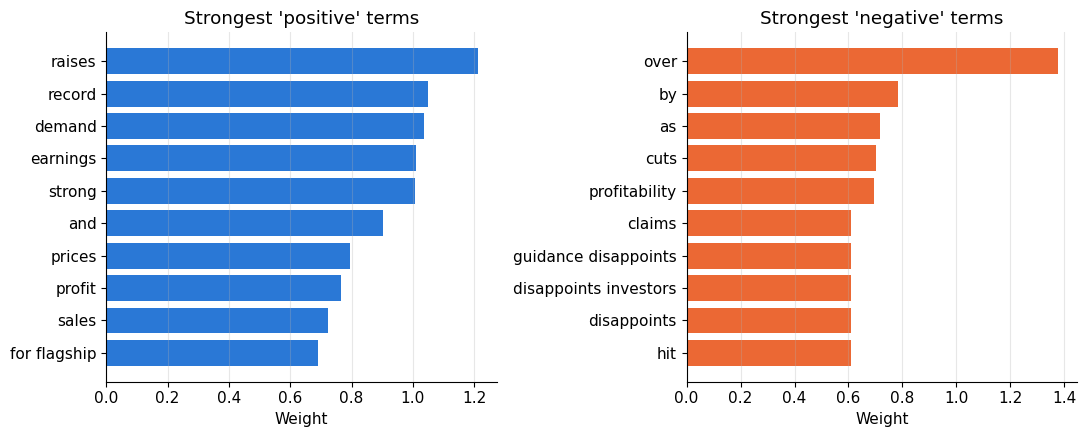

In [5]:
clf = make_classifier().fit(news["text"], y)          # fit on everything, just to inspect the weights
vocab = clf[0].get_feature_names_out()
coef = pd.DataFrame(clf[1].coef_.T, index=vocab, columns=clf[1].classes_)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cls, c in [(axes[0], "positive", COLORS[0]), (axes[1], "negative", COLORS[1])]:
    top = coef[cls].sort_values().tail(10)
    ax.barh(top.index, top.values, color=c)
    ax.set_title(f"Strongest '{cls}' terms")
    ax.grid(axis="y", visible=False)
axes[0].set_xlabel("Weight")
axes[1].set_xlabel("Weight")
plt.tight_layout()
plt.show()

Some learned weights make sense: "raises", "record", "strong" and "profit" for positive, "cuts" and "disappoints" for negative. But look at the others. "Over", "by", "as" and "and" are among the strongest signals. These are **spurious**: in this small dataset, negative headlines happen to use "over" ("fine over pipeline spill", "lawsuit over labels") and "as" more often. A model trained on 120 headlines learns the quirks of those 120 headlines. More data dilutes such accidents. Inspecting the weights, as here, is a cheap way to catch them.

### 4.6 New headlines

In [6]:
new_headlines = [
    "Profit rises as costs fall sharply",
    "Company writes down goodwill and suspends dividend",
    "Firm announces date of annual shareholder meeting",
    "Losses not as large as analysts feared",
    "Shares slide after regulator opens probe",
]
probs = pd.DataFrame(clf.predict_proba(new_headlines), columns=clf[1].classes_, index=new_headlines)
probs["classifier"] = clf.predict(new_headlines)
probs["lexicon"] = [lexicon_label(h) for h in new_headlines]
probs.round(2)

,negative,neutral,positive,classifier,lexicon
Profit rises as costs fall sharply,0.49,0.09,0.42,negative,positive
Company writes down goodwill and suspends dividend,0.43,0.22,0.34,negative,neutral
Firm announces date of annual shareholder meeting,0.16,0.75,0.09,neutral,neutral
Losses not as large as analysts feared,0.34,0.10,0.56,positive,negative
Shares slide after regulator opens probe,0.34,0.46,0.20,neutral,neutral


Neither method is reliable on new phrasing:

- "Profit rises as costs fall sharply": the lexicon gets it right. The classifier is torn between positive and negative, because "fall" and "as" pull towards negative.
- "Losses not as large as analysts feared": the classifier gets it right, which the lexicon can't, thanks to bigrams like "not as".
- "Writes down goodwill and suspends dividend": the classifier is right and the lexicon (neutral) misses it.
- "Shares slide after regulator opens probe": both miss it. Neither "slide" nor "probe" appeared in the training data or the word list.

Each approach fails differently, which is why practitioners often combine them, and why pretrained models that already know a lot of language are the usual next step.

### 4.7 The next step: pretrained language models

Modern NLP models are **pretrained** on billions of words before ever seeing your labels, so they already "understand" negation, comparisons and context. Two common options, not run here because they need large downloads or an API key:

**FinBERT**, a BERT model fine-tuned on financial text, via the `transformers` library:
```python
from transformers import pipeline
finbert = pipeline("text-classification", model="ProsusAI/finbert")
finbert("Losses not as large as analysts feared")
# -> [{'label': 'positive', 'score': ...}]
```

**A large language model (LLM)** asked to classify each headline with a fixed prompt. Powerful and flexible, but slower, more expensive per headline, and you must check that it gives consistent answers. Never let it see information from after the headline's timestamp (SAR4): an LLM trained on later data may already "know" how the story ended.

Whatever the model, evaluate it exactly as in this notebook: grouped, out-of-sample, and against a simple baseline.

## 5. Takeaways and where it breaks

- **TF-IDF + logistic regression is the standard text baseline.** It is fast and transparent, and every fancier model must beat it.
- **Learned models need honest splits.** Training accuracy is meaningless, and grouped splits stop the model learning *who* the news is about instead of *what* it says.
- **Small data limits learned models.** With 120 examples, the hand-made lexicon won by a wide margin. Learned models typically pull ahead only with thousands of labelled headlines.
- **Where it breaks:** our headlines are fictional, short and cleanly labelled. Real labels are noisy (people disagree about sentiment), language drifts over time, and good sentiment classification still has to be turned into returns, which needs the event study from SAR3.
- **Labels are the bottleneck.** Labelling a few hundred real headlines from the team's chosen source by hand is one of the most valuable things the team can do early on.

**What you could build:** a labelled dataset of real headlines from the team's chosen source, then a benchmark of lexicon vs. TF-IDF vs. FinBERT on it, evaluated with grouped, time-ordered splits.